# 04 Aggregate-Only Modeling

Notebook นี้ train และประเมินโมเดลโดยใช้ feature ระดับทีมและ feature ผลต่างระหว่าง Blue/Red ที่สร้างจากข้อมูลช่วง 10 นาทีแรก


## Feature Set Overview

Notebook นี้ใช้ข้อมูลที่สรุปสถานะเกมเป็นระดับทีม เช่น economy, combat, damage และ objective counts แล้วสร้าง column กลุ่ม `Blue_*`, `Red_*`, และ `Diff_*` สำหรับใช้เป็น input ของโมเดล


In [1]:
import sys
import os
os.environ["PYTHONIOENCODING"] = "utf-8"
try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, RocCurveDisplay, 
    ConfusionMatrixDisplay
)

import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from catboost import CatBoostClassifier


## 1. Load Data

อ่านไฟล์ `merged_v1.csv` จาก Kaggle input และตรวจ shape ของ dataframe


In [2]:
DATA_PATH = Path("data/t2_transformed/merged_v1.csv")

In [3]:
df = pd.read_csv(DATA_PATH)
df.shape

(91411, 145)

## 2. Basic Cleaning

ลบ identifier ที่ไม่ใช้เป็น feature, เก็บเฉพาะ row ที่ target ไม่ขัดกัน, ลบ `RedWin`, และใช้ `BlueWin` เป็น target


In [4]:
drop_id_cols = ["MatchFk", "Patch"]
df = df.drop(columns=[c for c in drop_id_cols if c in df.columns], errors="ignore")

In [5]:
df = df[df["BlueWin"] != df["RedWin"]].reset_index(drop=True)
df = df.drop(columns=["RedWin"], errors="ignore")

## 2.1 Target And Queue Distribution

แสดงสัดส่วน target และจำนวนข้อมูลในแต่ละ `QueueType` ก่อนเริ่ม encode และสร้าง feature


In [6]:
target_balance = (
    df["BlueWin"]
    .value_counts()
    .rename_axis("BlueWin")
    .reset_index(name="count")
)
target_balance["ratio"] = target_balance["count"] / target_balance["count"].sum()

display(target_balance)

if "QueueType" in df.columns:
    queue_summary = (
        df["QueueType"]
        .value_counts()
        .rename_axis("QueueType")
        .reset_index(name="count")
    )
    queue_summary["ratio"] = queue_summary["count"] / queue_summary["count"].sum()
    display(queue_summary)


,BlueWin,count,ratio
0,1,45702,0.500055
1,0,45692,0.499945


,QueueType,count,ratio
0,CLASSIC,81028,0.886579
1,SWIFTPLAY,6515,0.071285
2,CHERRY,1838,0.020111
3,ARAM,1375,0.015045
4,URF,638,0.006981


In [7]:
lane_cols = [f"Lane_P{p}" for p in range(1, 11)]
for c in lane_cols:
    df[c] = df[c].replace("NONE", "JUNGLE")

## 3. Encode Categorical Features

แปลง column ประเภทข้อความด้วย one-hot encoding เพื่อให้ใช้กับโมเดล scikit-learn และ boosting libraries ได้


In [8]:
ohe_cols = df.select_dtypes(include="object").columns.tolist()

df = pd.get_dummies(df, columns=ohe_cols)

## 4. Feature Engineering

สร้าง feature ระดับทีมจากข้อมูลผู้เล่น เช่น ผลรวม ค่าเฉลี่ย และผลต่างของ gold, CS, kills, deaths, assists และ damage รวมถึง KDA และ objective differences


In [9]:
# --- Team-level aggregates ---
blue_players = [f"P{i}" for i in range(1, 6)]
red_players  = [f"P{i}" for i in range(6, 11)]

for stat in ["TotalGold", "MinionsKilled", "kills", "deaths", "assists", "DmgDealt"]:
    blue_cols = [f"{stat}_{p}" for p in blue_players]
    red_cols  = [f"{stat}_{p}" for p in red_players]
    df[f"Blue_{stat}_sum"] = df[blue_cols].sum(axis=1)
    df[f"Red_{stat}_sum"]  = df[red_cols].sum(axis=1)
    df[f"Blue_{stat}_avg"] = df[blue_cols].mean(axis=1)
    df[f"Red_{stat}_avg"]  = df[red_cols].mean(axis=1)
    df[f"Diff_{stat}"]     = df[f"Blue_{stat}_sum"] - df[f"Red_{stat}_sum"]

# --- KDA ---
def safe_kda(k, d, a):
    return (k + a) / d.replace(0, 1)

df["Blue_KDA"] = safe_kda(df["Blue_kills_sum"], df["Blue_deaths_sum"], df["Blue_assists_sum"])
df["Red_KDA"]  = safe_kda(df["Red_kills_sum"],  df["Red_deaths_sum"],  df["Red_assists_sum"])
df["Diff_KDA"] = df["Blue_KDA"] - df["Red_KDA"]

# --- Objective differentials (already team-level) ---
for obj in ["BaronKills", "RiftHeraldKills", "DragonKills", "TowerKills"]:
    df[f"Diff_{obj}"] = df[f"Blue{obj}"] - df[f"Red{obj}"]

# Kill differential (already team-level)
df["Diff_Kills"] = df["BlueKills"] - df["RedKills"]

# --- Gold share (how evenly gold is distributed) ---
for side, players in [("Blue", blue_players), ("Red", red_players)]:
    gold_cols = [f"TotalGold_{p}" for p in players]
    df[f"{side}_GoldStd"] = df[gold_cols].std(axis=1)

## 5. Select Aggregate Feature Set

เลือกเฉพาะ feature ที่เป็น team aggregate, difference feature และ objective count เพื่อสร้างชุดข้อมูลแบบ aggregate-only


In [10]:
# Strategy A — "Aggregate-only" (team-level features, no per-player columns)
agg_feature_cols = [c for c in df.columns if c.startswith(("Blue_", "Red_", "Diff_"))]

# Include objective raw counts because EDA shows that map control matters at 10 minutes.
raw_objective_cols = [
    "BlueBaronKills", "BlueRiftHeraldKills", "BlueDragonKills", "BlueTowerKills", "BlueKills",
    "RedBaronKills", "RedRiftHeraldKills", "RedDragonKills", "RedTowerKills", "RedKills",
]
agg_feature_cols += [c for c in raw_objective_cols if c in df.columns]

# Deduplicate and keep only existing columns.
agg_feature_cols = sorted(set(c for c in agg_feature_cols if c in df.columns))

def aggregate_feature_group(col):
    if col.startswith("Diff_"):
        return "difference_features"
    if col in raw_objective_cols:
        return "raw_objective_counts"
    if col.startswith(("Blue_", "Red_")):
        return "team_aggregate_features"
    return "other"

feature_group_summary = (
    pd.Series([aggregate_feature_group(c) for c in agg_feature_cols])
    .value_counts()
    .rename_axis("feature_group")
    .reset_index(name="feature_count")
)

feature_set_summary = pd.DataFrame([
    {"item": "Rows", "value": len(df)},
    {"item": "Aggregate-only feature count", "value": len(agg_feature_cols)},
    {"item": "Blue win ratio", "value": df["BlueWin"].mean()},
    {"item": "Primary metric", "value": "AUC-ROC"},
])

display(feature_set_summary)
display(feature_group_summary)


,item,value
0,Rows,91394
1,Aggregate-only feature count,50
2,Blue win ratio,0.500055
3,Primary metric,AUC-ROC


,feature_group,feature_count
0,team_aggregate_features,28
1,difference_features,12
2,raw_objective_counts,10


## 6. Train / Validation / Test Split

แบ่งข้อมูลเป็น train, validation และ test แบบ stratified และสร้างทั้งชุด scaled และ unscaled สำหรับโมเดลที่ต้องการ preprocessing ต่างกัน


In [11]:
def prepare_data(df, feature_cols=None, target="BlueWin", val_size=0.15, test_size=0.15, random_state=1337, scale=False):

    if feature_cols is None:
        feature_cols = [c for c in df.columns if c != target]

    X = df[feature_cols].copy()
    y = df[target].copy()

    temp_size = val_size + test_size
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=temp_size, random_state=random_state, stratify=y
    )

    relative_test_size = test_size / temp_size
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=relative_test_size, random_state=random_state, stratify=y_temp
    )

    scaler = None
    X_train_sc, X_val_sc, X_test_sc = X_train, X_val, X_test

    if scale:
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_val_sc   = scaler.transform(X_val)
        X_test_sc  = scaler.transform(X_test)

    return {
        "X_train": X_train_sc,
        "X_val":   X_val_sc,
        "X_test":  X_test_sc,
        "y_train": y_train,
        "y_val":   y_val,
        "y_test":  y_test,
        "scaler":  scaler
    }

def unpack_data(data):
    return (
        data["X_train"],
        data["X_val"],
        data["X_test"],
        data["y_train"],
        data["y_val"],
        data["y_test"],
    )

In [12]:
data_sc = prepare_data(df, feature_cols=agg_feature_cols, scale=True)
X_train_sc, X_val_sc, X_test_sc, y_train, y_val, y_test = unpack_data(data_sc)

data = prepare_data(df, feature_cols=agg_feature_cols)
X_train, X_val, X_test, y_train, y_val, y_test = unpack_data(data)

## 7. Evaluation Helper

นิยาม helper function สำหรับ train model, predict test set, คำนวณ Accuracy, AUC และ F1 แล้วเก็บผลลัพธ์ใน dictionary


In [13]:
def train_and_evaluate(name, model, data, results=None):
    if results is None:
        results = {}

    X_train, X_val, X_test, y_train, y_val, y_test = unpack_data(data)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred)

    results[name] = {
        "model":  model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "acc":    acc,
        "auc":    auc,
        "f1":     f1,
    }

    print(f" > {name}")
    print(f"   Accuracy: {acc:.4f}  |  AUC: {auc:.4f}  |  F1: {f1:.4f}")

    return results

## 8. Hyperparameter Tuning With Optuna

นิยาม objective functions ของแต่ละโมเดลสำหรับ Optuna โดยใช้ validation AUC เป็นค่าที่ optimize และตั้งค่า GPU fallback สำหรับ XGBoost, LightGBM และ CatBoost


In [14]:
N_TRIALS = 50
USE_GPU = True
GPU_FALLBACK_TO_CPU = True

def gpu_params_for(model_name):
    if not USE_GPU:
        return {}

    if model_name == "XGBoost":
        return {
            "tree_method": "hist",
            "device": "cuda",
        }

    if model_name == "LightGBM":
        return {
            "device_type": "gpu",
        }

    if model_name == "CatBoost":
        return {
            "task_type": "GPU",
            "devices": "0",
        }

    return {}


def fit_with_optional_gpu_fallback(model_name, build_model, fit_fn):
    model = build_model(use_gpu=USE_GPU)

    try:
        fit_fn(model)
        return model

    except Exception as exc:
        can_fallback = (
            USE_GPU
            and GPU_FALLBACK_TO_CPU
            and model_name in {"XGBoost", "LightGBM", "CatBoost"}
        )

        if not can_fallback:
            raise

        print(f"GPU failed for {model_name}; retrying on CPU.")
        print(f"Reason: {type(exc).__name__}: {exc}")

        model = build_model(use_gpu=False)
        fit_fn(model)
        return model


def obj_logreg(trial):
    m = LogisticRegression(
        C=1.0,
        solver="lbfgs",
        penalty="l2",
        max_iter=500,
        random_state=42,
    )

    m.fit(X_train_sc, y_train)
    return roc_auc_score(y_val, m.predict_proba(X_val_sc)[:, 1])


def obj_dt(trial):
    m = DecisionTreeClassifier(
        max_depth=trial.suggest_int("max_depth", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 30),
        max_features=trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None],
        ),
        random_state=42,
    )

    m.fit(X_train.values, y_train.values)
    return roc_auc_score(y_val, m.predict_proba(X_val.values)[:, 1])


def obj_rf(trial):
    m = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 300, step=50),
        max_depth=trial.suggest_int("max_depth", 6, 16),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 2, 20),
        max_features=trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"],
        ),
        bootstrap=True,
        max_samples=trial.suggest_categorical(
            "max_samples",
            [0.5, 0.75],
        ),
        random_state=42,
        n_jobs=-1,
    )

    m.fit(X_train.values, y_train.values)
    return roc_auc_score(y_val, m.predict_proba(X_val.values)[:, 1])


def obj_xgb(trial):
    params = {
        "n_estimators": 800,
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "eval_metric": "logloss",
        "early_stopping_rounds": 50,
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": 0,
    }

    def build_model(use_gpu):
        if use_gpu:
            gpu_params = {
                **gpu_params_for("XGBoost"),
                "sampling_method": "gradient_based",
            }
        else:
            gpu_params = {
                "tree_method": "hist",
                "sampling_method": "uniform",
            }

        return xgb.XGBClassifier(**params, **gpu_params)

    m = fit_with_optional_gpu_fallback(
        "XGBoost",
        build_model,
        lambda model: model.fit(
            X_train.values,
            y_train.values,
            eval_set=[(X_val.values, y_val.values)],
            verbose=False,
        ),
    )

    return roc_auc_score(y_val, m.predict_proba(X_val.values)[:, 1])



def obj_lgb(trial):
    params = {
        "n_estimators": 800,
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    def build_model(use_gpu):
        gpu_params = gpu_params_for("LightGBM") if use_gpu else {}
        return lgb.LGBMClassifier(**params, **gpu_params)

    m = fit_with_optional_gpu_fallback(
        "LightGBM",
        build_model,
        lambda model: model.fit(
            X_train.values,
            y_train.values,
            eval_set=[(X_val.values, y_val.values)],
            callbacks=[lgb.early_stopping(50, verbose=False)],
        ),
    )

    return roc_auc_score(y_val, m.predict_proba(X_val.values)[:, 1])


def obj_catboost(trial):
    params = {
        "iterations": 800,
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 10, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 5, log=True),
        "random_seed": 42,
        "verbose": 0,
        "early_stopping_rounds": 50,
    }

    def build_model(use_gpu):
        gpu_params = gpu_params_for("CatBoost") if use_gpu else {}
        return CatBoostClassifier(**params, **gpu_params)

    m = fit_with_optional_gpu_fallback(
        "CatBoost",
        build_model,
        lambda model: model.fit(
            X_train.values,
            y_train.values,
            eval_set=(X_val.values, y_val.values),
        ),
    )

    return roc_auc_score(y_val, m.predict_proba(X_val.values)[:, 1])


## 9. Run Tuning

รัน Optuna ตามจำนวน trials ที่กำหนดใน `MODEL_TRIALS` แล้วเก็บ best validation AUC และ best parameters ของแต่ละโมเดล


In [15]:
OUTPUT_DIR = Path("outputs/aggregate_only")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_PARAMS_PATH = OUTPUT_DIR / "best_params.csv"
SUMMARY_PATH = OUTPUT_DIR / "summary.csv"
USE_CACHED_BEST_PARAMS = True

objectives = {
    "LogisticRegression": obj_logreg,
    "DecisionTree": obj_dt,
    "RandomForest": obj_rf,
    "XGBoost": obj_xgb,
    "LightGBM": obj_lgb,
    "CatBoost": obj_catboost,
}

MODEL_TRIALS = {
    "LogisticRegression": 1,
    "DecisionTree": 100,
    "RandomForest": 100,
    "XGBoost": 100,
    "LightGBM": 100,
    "CatBoost": 100,
}

INT_PARAMS = {
    "max_depth",
    "min_samples_leaf",
    "min_samples_split",
    "n_estimators",
    "min_child_weight",
    "num_leaves",
    "min_child_samples",
    "depth",
}

def clean_cached_param_value(key, value):
    if pd.isna(value) or value == "":
        return None
    if isinstance(value, str):
        value = value.strip()
        if value == "" or value.lower() == "nan":
            return None
        if value == "None":
            return None
    if key in INT_PARAMS:
        return int(float(value))
    if isinstance(value, str):
        try:
            return float(value)
        except ValueError:
            return value
    return value

def load_cached_best_params(best_params_path=BEST_PARAMS_PATH, summary_path=SUMMARY_PATH):
    if not best_params_path.exists():
        return None

    params_table = pd.read_csv(best_params_path, index_col=0)
    summary_table = pd.read_csv(summary_path, index_col=0) if summary_path.exists() else pd.DataFrame()
    cached = {}

    for model_name in objectives:
        if model_name not in params_table.index:
            return None

        row = params_table.loc[model_name]
        params = {}
        for key, value in row.items():
            cleaned = clean_cached_param_value(key, value)
            if cleaned is not None:
                params[key] = cleaned

        val_auc = np.nan
        if model_name in summary_table.index and "Val_AUC" in summary_table.columns:
            val_auc = float(summary_table.loc[model_name, "Val_AUC"])

        cached[model_name] = {
            "best_params": params,
            "val_auc": val_auc,
            "source": "cached_best_params",
        }

    return cached

tuned_results = load_cached_best_params() if USE_CACHED_BEST_PARAMS else None
studies = {}

if tuned_results is not None:
    print(f"Loaded cached best parameters from {BEST_PARAMS_PATH}")
    if SUMMARY_PATH.exists():
        print(f"Loaded cached validation AUC values from {SUMMARY_PATH}")
else:
    tuned_results = {}
    for name, obj_fn in objectives.items():
        n_trials = MODEL_TRIALS.get(name, N_TRIALS)

        print(f"\n  > Tuning {name} ({n_trials} trials) ...")
        study = optuna.create_study(direction="maximize", study_name=name)
        study.optimize(obj_fn, n_trials=n_trials, show_progress_bar=False)
        studies[name] = study

        tuned_results[name] = {
            "best_params": study.best_params.copy(),
            "val_auc": float(study.best_value),
            "source": "optuna",
        }

        print(f"Best Val AUC: {study.best_value:.4f}")
        print(f"Best Params:  {study.best_params}")


Loaded cached best parameters from outputs\aggregate_only\best_params.csv
Loaded cached validation AUC values from outputs\aggregate_only\summary.csv


## 10. Retrain Tuned Models And Evaluate Test Set

สร้างโมเดลใหม่จาก best parameters ของแต่ละ study, train อีกครั้ง และประเมินผลบน test set


In [16]:
def build_best_model(name, params, use_gpu=USE_GPU):
    if name == "LogisticRegression":
        return LogisticRegression(C=1.0, solver="lbfgs", penalty="l2", max_iter=500, random_state=42)
    if name == "DecisionTree":
        return DecisionTreeClassifier(**params, random_state=42)
    if name == "RandomForest":
        return RandomForestClassifier(**params, bootstrap=True, random_state=42, n_jobs=-1)
    if name == "XGBoost":
        if use_gpu:
            gpu_params = {**gpu_params_for("XGBoost"), "sampling_method": "gradient_based"}
        else:
            gpu_params = {"tree_method": "hist", "sampling_method": "uniform"}
        return xgb.XGBClassifier(
            **params,
            n_estimators=800,
            eval_metric="logloss",
            early_stopping_rounds=50,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            **gpu_params,
        )
    if name == "LightGBM":
        gpu_params = gpu_params_for("LightGBM") if use_gpu else {}
        return lgb.LGBMClassifier(
            **params,
            n_estimators=800,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
            **gpu_params,
        )
    if name == "CatBoost":
        gpu_params = gpu_params_for("CatBoost") if use_gpu else {}
        return CatBoostClassifier(
            **params,
            iterations=800,
            random_seed=42,
            verbose=0,
            early_stopping_rounds=50,
            **gpu_params,
        )
    raise ValueError(f"Unknown model name: {name}")

results = {}

for name, tuned in tuned_results.items():
    bp = tuned["best_params"].copy()
    val_auc = tuned["val_auc"]
    uses_scaled = name == "LogisticRegression"
    Xtr = X_train_sc if uses_scaled else X_train.values
    Xv = X_val_sc if uses_scaled else X_val.values
    Xte = X_test_sc if uses_scaled else X_test.values

    def fit_model(model):
        if name == "XGBoost":
            model.fit(Xtr, y_train.values, eval_set=[(Xv, y_val.values)], verbose=False)
        elif name == "LightGBM":
            model.fit(
                Xtr,
                y_train.values,
                eval_set=[(Xv, y_val.values)],
                callbacks=[lgb.early_stopping(50, verbose=False)],
            )
        elif name == "CatBoost":
            model.fit(Xtr, y_train.values, eval_set=(Xv, y_val.values))
        else:
            model.fit(Xtr, y_train.values)

    model = fit_with_optional_gpu_fallback(
        name,
        lambda use_gpu: build_best_model(name, bp, use_gpu=use_gpu),
        fit_model,
    )

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "acc": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "f1": f1_score(y_test, y_pred),
        "best_params": bp.copy(),
        "val_auc": val_auc,
    }

    print(f"\n> {name}")
    val_auc_text = "N/A" if pd.isna(val_auc) else f"{val_auc:.4f}"
    print(f"  Val AUC:  {val_auc_text}")
    print(f"  Test Acc: {results[name]['acc']:.4f} | Test AUC: {results[name]['auc']:.4f} | Test F1: {results[name]['f1']:.4f}")



> LogisticRegression
  Val AUC:  0.7722
  Test Acc: 0.7036 | Test AUC: 0.7812 | Test F1: 0.7012

> DecisionTree
  Val AUC:  0.7631
  Test Acc: 0.6996 | Test AUC: 0.7743 | Test F1: 0.6938

> RandomForest
  Val AUC:  0.7713
  Test Acc: 0.7033 | Test AUC: 0.7801 | Test F1: 0.6997

> XGBoost
  Val AUC:  0.7732
  Test Acc: 0.7034 | Test AUC: 0.7817 | Test F1: 0.6991

> LightGBM
  Val AUC:  0.7729
  Test Acc: 0.7042 | Test AUC: 0.7818 | Test F1: 0.7001
GPU failed for CatBoost; retrying on CPU.
Reason: CatBoostError: catboost/cuda/cuda_lib/cuda_base.h:265: CUDA error 35: CUDA driver version is insufficient for CUDA runtime version

> CatBoost
  Val AUC:  0.7734
  Test Acc: 0.7031 | Test AUC: 0.7822 | Test F1: 0.6994


## 11. Numeric Model Comparison And Feature Importance

สร้างตาราง metric ของทุกโมเดล, เลือก best model จาก `Test_AUC`, เปรียบเทียบกับ Logistic Regression และแสดง feature importance ของสองโมเดลนี้



4. NUMERIC MODEL COMPARISON


,Val_AUC,Test_Accuracy,Test_AUC,Test_F1,AUC_Rank,Gap_vs_Best_AUC,Gap_vs_LogReg_AUC
CatBoost,0.773388,0.703136,0.782246,0.699409,1,0.000000,0.001004
LightGBM,0.772869,0.704158,0.781830,0.700089,2,0.000416,0.000587
XGBoost,0.773156,0.703428,0.781741,0.699082,3,0.000505,0.000499
LogisticRegression,0.772192,0.703647,0.781242,0.701228,4,0.001004,0.000000
RandomForest,0.771255,0.703282,0.780066,0.699734,5,0.002180,-0.001176
DecisionTree,0.763067,0.699562,0.774315,0.693823,6,0.007931,-0.006927


,AUC_Rank,Val_AUC,Test_AUC,Test_Accuracy,Test_F1,Gap_vs_Best_AUC,Gap_vs_LogReg_AUC
LogisticRegression,4,0.772192,0.781242,0.703647,0.701228,0.001004,0.000000
CatBoost,1,0.773388,0.782246,0.703136,0.699409,0.000000,0.001004


Best model by Test AUC: CatBoost
Logistic Regression Test AUC: 0.7812
Best Model Test AUC: 0.7822
AUC gap (Best - Logistic): +0.0010


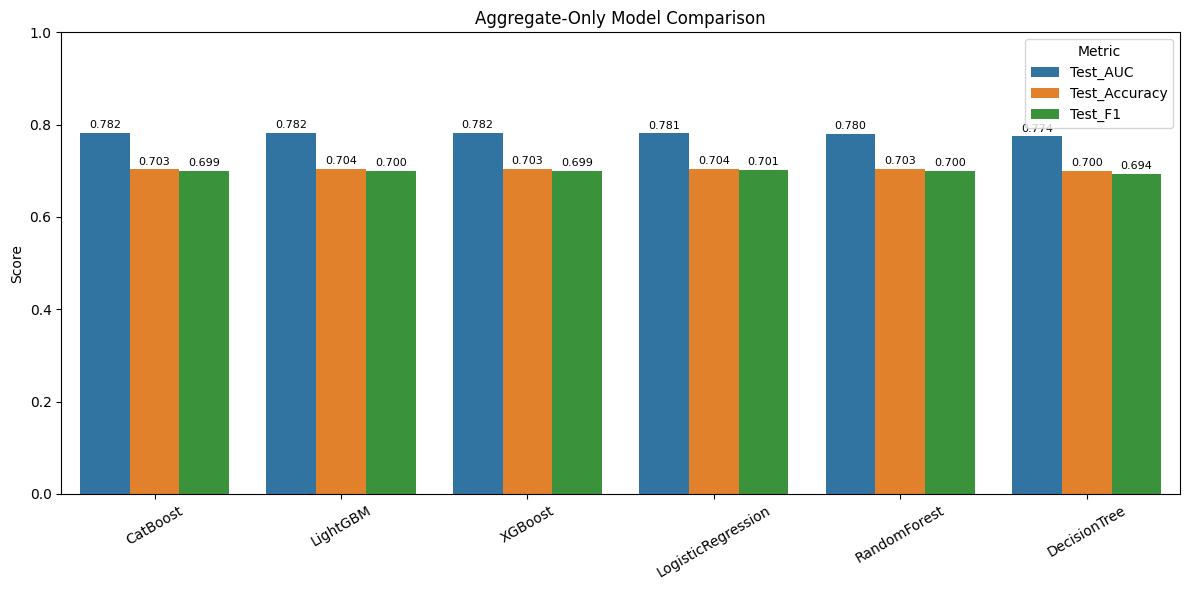

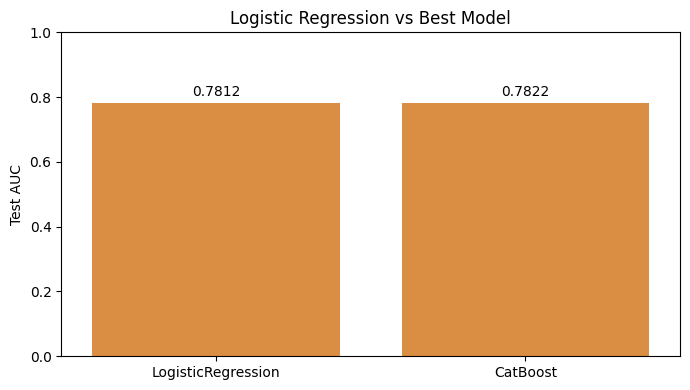

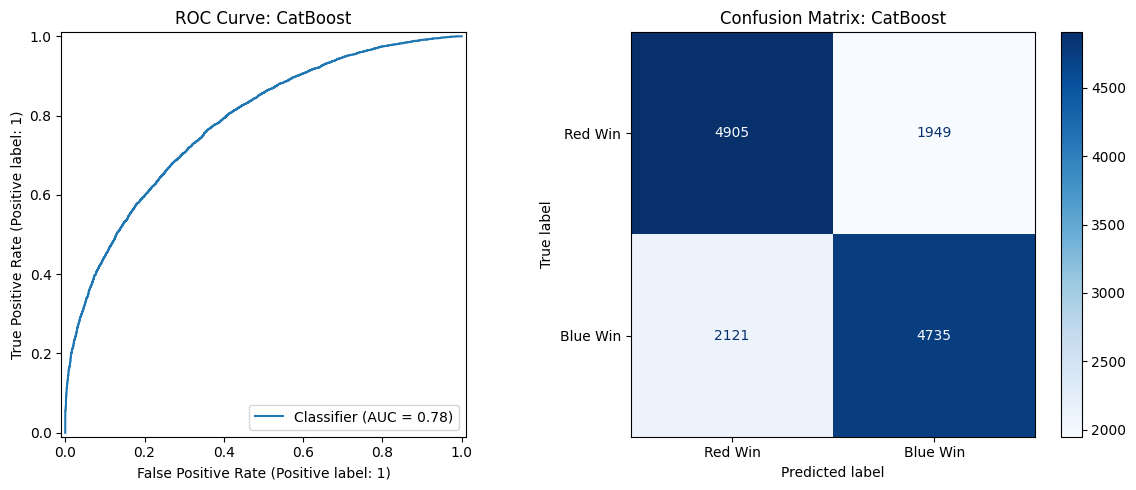


Classification Report: Best Model
              precision    recall  f1-score   support

     Red Win       0.70      0.72      0.71      6854
    Blue Win       0.71      0.69      0.70      6856

    accuracy                           0.70     13710
   macro avg       0.70      0.70      0.70     13710
weighted avg       0.70      0.70      0.70     13710


Classification Report: Logistic Regression
              precision    recall  f1-score   support

     Red Win       0.70      0.71      0.71      6854
    Blue Win       0.71      0.70      0.70      6856

    accuracy                           0.70     13710
   macro avg       0.70      0.70      0.70     13710
weighted avg       0.70      0.70      0.70     13710



,model,importance_rank,feature,importance,raw_value,direction,feature_group
0,LogisticRegression,1,RedKills,1.701585,1.701585,Blue-favored,raw_objective_counts
1,LogisticRegression,2,Diff_Kills,0.958660,-0.958660,Red-favored,difference_features
2,LogisticRegression,3,BlueKills,0.928144,0.928144,Blue-favored,raw_objective_counts
3,LogisticRegression,4,Red_kills_sum,0.788195,-0.788195,Red-favored,team_aggregate_features
4,LogisticRegression,5,Red_kills_avg,0.788195,-0.788195,Red-favored,team_aggregate_features
5,LogisticRegression,6,Diff_kills,0.537567,0.537567,Blue-favored,difference_features
6,LogisticRegression,7,Diff_TotalGold,0.497377,0.497377,Blue-favored,difference_features
7,LogisticRegression,8,Diff_MinionsKilled,0.193474,0.193474,Blue-favored,difference_features
8,LogisticRegression,9,Blue_kills_avg,0.176030,-0.176030,Red-favored,team_aggregate_features
9,LogisticRegression,10,Blue_kills_sum,0.176030,-0.176030,Red-favored,team_aggregate_features


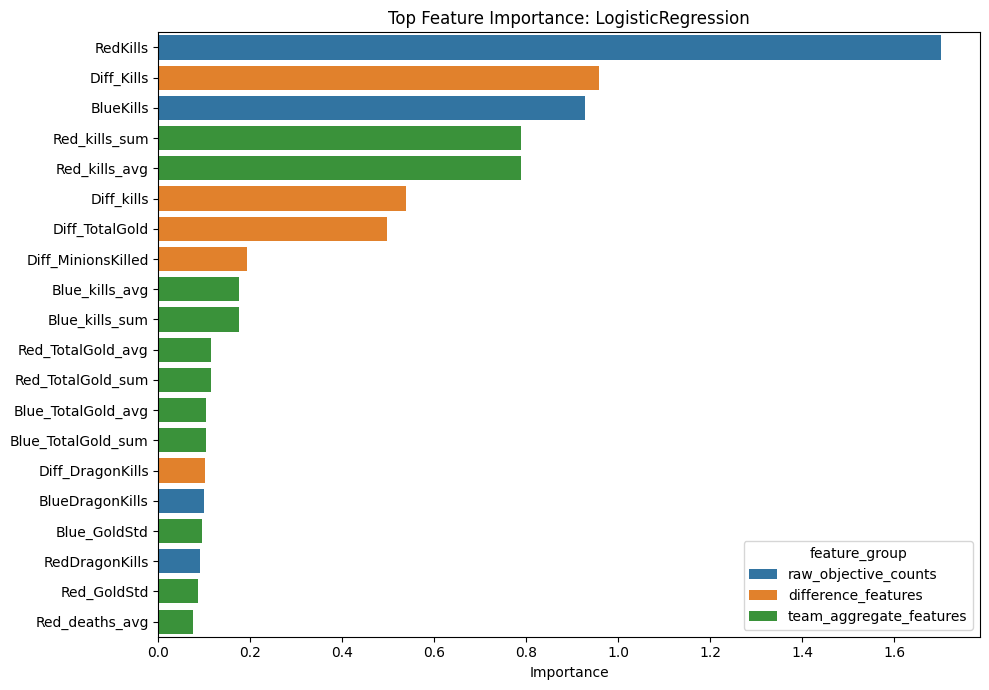

,model,importance_rank,feature,importance,raw_value,direction,feature_group
50,CatBoost,1,Diff_TotalGold,19.639550,19.639550,higher importance,difference_features
51,CatBoost,2,Red_MinionsKilled_sum,8.738997,8.738997,higher importance,team_aggregate_features
52,CatBoost,3,Red_MinionsKilled_avg,8.480658,8.480658,higher importance,team_aggregate_features
53,CatBoost,4,Blue_MinionsKilled_avg,6.975754,6.975754,higher importance,team_aggregate_features
54,CatBoost,5,Blue_MinionsKilled_sum,5.847505,5.847505,higher importance,team_aggregate_features
55,CatBoost,6,Diff_MinionsKilled,5.758919,5.758919,higher importance,difference_features
56,CatBoost,7,Red_GoldStd,3.060238,3.060238,higher importance,team_aggregate_features
57,CatBoost,8,Diff_DragonKills,2.987939,2.987939,higher importance,difference_features
58,CatBoost,9,RedDragonKills,2.919703,2.919703,higher importance,raw_objective_counts
59,CatBoost,10,Diff_Kills,2.817965,2.817965,higher importance,difference_features


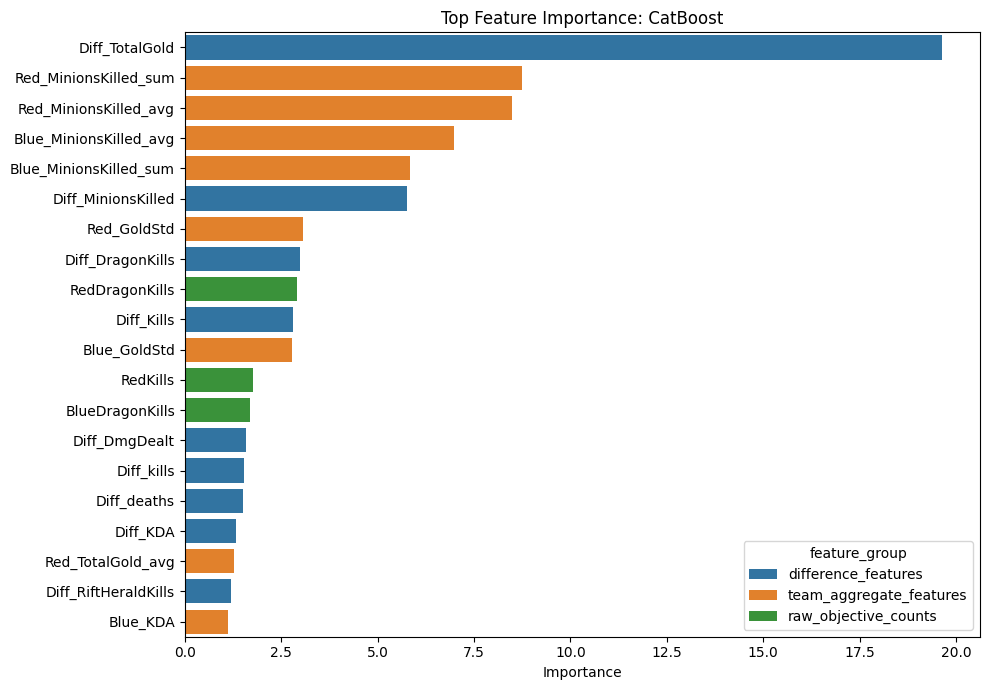

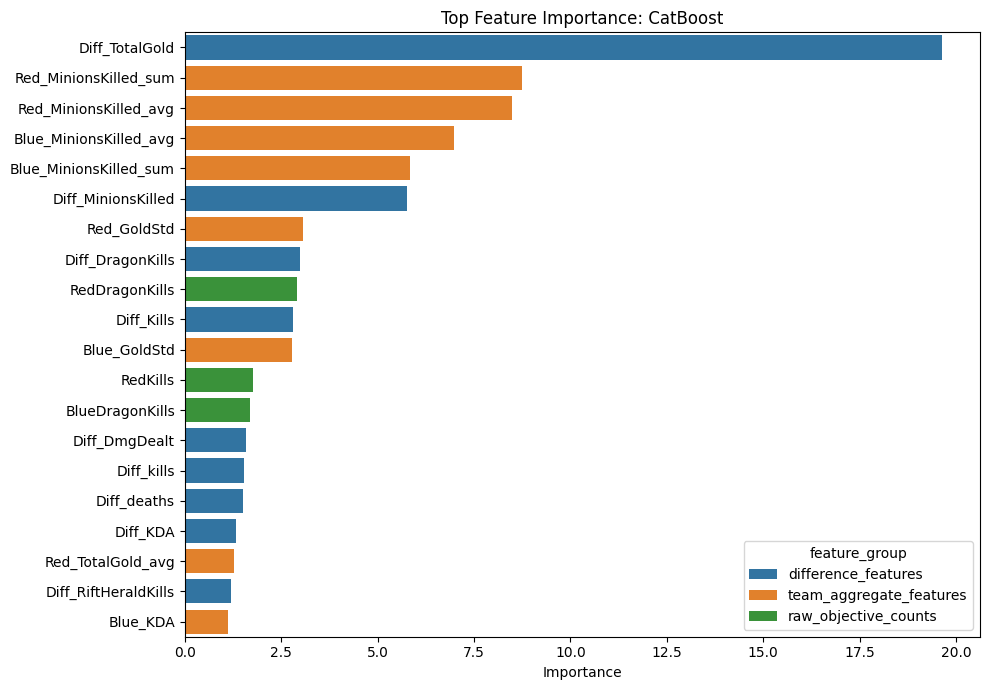

In [17]:
print("\n" + "=" * 60)
print("4. NUMERIC MODEL COMPARISON")
print("=" * 60)

OUTPUT_DIR = Path("outputs/aggregate_only")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary = pd.DataFrame({
    name: {
        "Val_AUC": r["val_auc"],
        "Test_Accuracy": r["acc"],
        "Test_AUC": r["auc"],
        "Test_F1": r["f1"],
    }
    for name, r in results.items()
}).T.sort_values("Test_AUC", ascending=False)

summary["AUC_Rank"] = summary["Test_AUC"].rank(ascending=False, method="min").astype(int)
summary["Gap_vs_Best_AUC"] = summary["Test_AUC"].max() - summary["Test_AUC"]
summary["Gap_vs_LogReg_AUC"] = summary["Test_AUC"] - summary.loc["LogisticRegression", "Test_AUC"]

display(summary)
summary.to_csv(OUTPUT_DIR / "summary.csv")
summary.to_csv(OUTPUT_DIR / "model_numeric_comparison.csv")

params_df = pd.DataFrame({name: r["best_params"] for name, r in results.items()}).T
params_df.to_csv(OUTPUT_DIR / "best_params.csv")

best_name = summary.index[0]
best_result = results[best_name]

key_model_names = ["LogisticRegression"]
if best_name not in key_model_names:
    key_model_names.append(best_name)

key_model_summary = summary.loc[key_model_names, [
    "AUC_Rank",
    "Val_AUC",
    "Test_AUC",
    "Test_Accuracy",
    "Test_F1",
    "Gap_vs_Best_AUC",
    "Gap_vs_LogReg_AUC",
]]
display(key_model_summary)
key_model_summary.to_csv(OUTPUT_DIR / "logreg_vs_best_summary.csv")

print(f"Best model by Test AUC: {best_name}")
print(f"Logistic Regression Test AUC: {summary.loc['LogisticRegression', 'Test_AUC']:.4f}")
print(f"Best Model Test AUC: {best_result['auc']:.4f}")
print(f"AUC gap (Best - Logistic): {best_result['auc'] - summary.loc['LogisticRegression', 'Test_AUC']:+.4f}")

# --- Visual model comparison: all models, numeric metrics only ---
metrics = ["Test_AUC", "Test_Accuracy", "Test_F1"]
summary_long = (
    summary
    .reset_index()
    .rename(columns={"index": "Model"})
    .melt(
        id_vars="Model",
        value_vars=metrics,
        var_name="Metric",
        value_name="Score",
    )
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=summary_long, x="Model", y="Score", hue="Metric")
ax.set_title("Aggregate-Only Model Comparison")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
key_plot = key_model_summary.reset_index().rename(columns={"index": "Model"})
ax = sns.barplot(data=key_plot, x="Model", y="Test_AUC", color="#F28E2B")
ax.set_title("Logistic Regression vs Best Model")
ax.set_xlabel("")
ax.set_ylabel("Test AUC")
ax.set_ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=10, padding=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "logreg_vs_best_auc.png", dpi=150, bbox_inches="tight")
plt.show()

# --- ROC curve and confusion matrix for best model ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, best_result["y_prob"], ax=axes[0])
axes[0].set_title(f"ROC Curve: {best_name}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_result["y_pred"],
    display_labels=["Red Win", "Blue Win"],
    cmap="Blues",
    ax=axes[1],
)
axes[1].set_title(f"Confusion Matrix: {best_name}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "best_model_eval.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassification Report: Best Model")
print(classification_report(y_test, best_result["y_pred"], target_names=["Red Win", "Blue Win"]))

if best_name != "LogisticRegression":
    print("\nClassification Report: Logistic Regression")
    print(classification_report(y_test, results["LogisticRegression"]["y_pred"], target_names=["Red Win", "Blue Win"]))

def build_feature_signal_table(model_name, feature_cols, feature_group_fn):
    model = results[model_name]["model"]
    if hasattr(model, "coef_"):
        table = pd.DataFrame({
            "model": model_name,
            "feature": feature_cols,
            "raw_value": model.coef_[0],
        })
        table["importance"] = table["raw_value"].abs()
        table["direction"] = np.where(table["raw_value"] >= 0, "Blue-favored", "Red-favored")
        table["importance_type"] = "absolute_logistic_coefficient"
    elif hasattr(model, "feature_importances_"):
        table = pd.DataFrame({
            "model": model_name,
            "feature": feature_cols,
            "raw_value": model.feature_importances_,
            "importance": model.feature_importances_,
        })
        table["direction"] = "higher importance"
        table["importance_type"] = "tree_feature_importance"
    else:
        return None

    table["feature_group"] = table["feature"].map(feature_group_fn)
    table = table.sort_values("importance", ascending=False).reset_index(drop=True)
    table["importance_rank"] = np.arange(1, len(table) + 1)
    return table

feature_signal_tables = []
for model_name in key_model_names:
    table = build_feature_signal_table(model_name, agg_feature_cols, aggregate_feature_group)
    if table is not None:
        feature_signal_tables.append(table)

if feature_signal_tables:
    feature_importance_df = pd.concat(feature_signal_tables, ignore_index=True)
    feature_importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

    for model_name in key_model_names:
        model_signals = feature_importance_df[feature_importance_df["model"] == model_name].head(20)
        if model_signals.empty:
            continue

        display(model_signals[[
            "model", "importance_rank", "feature", "importance", "raw_value", "direction", "feature_group"
        ]])

        plt.figure(figsize=(10, 7))
        sns.barplot(data=model_signals, x="importance", y="feature", hue="feature_group", dodge=False)
        plt.title(f"Top Feature Importance: {model_name}")
        plt.xlabel("Importance")
        plt.ylabel("")
        plt.tight_layout()
        safe_name = model_name.lower().replace(" ", "_")
        plt.savefig(OUTPUT_DIR / f"feature_importance_{safe_name}.png", dpi=150, bbox_inches="tight")
        plt.show()

    generic_model = best_name if best_name in key_model_names else key_model_names[0]
    generic_signals = feature_importance_df[feature_importance_df["model"] == generic_model].head(20)
    if not generic_signals.empty:
        plt.figure(figsize=(10, 7))
        sns.barplot(data=generic_signals, x="importance", y="feature", hue="feature_group", dodge=False)
        plt.title(f"Top Feature Importance: {generic_model}")
        plt.xlabel("Importance")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("Selected models do not expose coefficients or feature_importances_.")


## 12. Train Final Model With Train + Validation

train final model ด้วยข้อมูล train และ validation รวมกัน แล้วประเมินบน test set เดิม พร้อมบันทึก metric และ model artifact


In [18]:
print("\n" + "=" * 60)
print("5. Training the final selected model on TRAIN + VALIDATION ...")
print("=" * 60)

def best_iteration_from_fitted_model(name, fitted_model):
    if name == "XGBoost":
        best_iteration = getattr(fitted_model, "best_iteration", None)
        return None if best_iteration is None else int(best_iteration) + 1
    if name == "LightGBM":
        best_iteration = getattr(fitted_model, "best_iteration_", None)
        return None if best_iteration is None or best_iteration <= 0 else int(best_iteration)
    if name == "CatBoost":
        best_iteration = fitted_model.get_best_iteration()
        return None if best_iteration is None else int(best_iteration) + 1
    return None

def build_final_model(name, params, tuned_model=None, use_gpu=USE_GPU):
    params = params.copy()
    best_n_estimators = best_iteration_from_fitted_model(name, tuned_model) if tuned_model is not None else None

    if name == "LogisticRegression":
        return LogisticRegression(C=1.0, solver="lbfgs", penalty="l2", max_iter=500, random_state=42)
    if name == "DecisionTree":
        return DecisionTreeClassifier(**params, random_state=42)
    if name == "RandomForest":
        return RandomForestClassifier(**params, bootstrap=True, random_state=42, n_jobs=-1)
    if name == "XGBoost":
        if best_n_estimators is not None:
            params["n_estimators"] = best_n_estimators
        if use_gpu:
            gpu_params = {**gpu_params_for("XGBoost"), "sampling_method": "gradient_based"}
        else:
            gpu_params = {"tree_method": "hist", "sampling_method": "uniform"}
        return xgb.XGBClassifier(**params, eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0, **gpu_params)
    if name == "LightGBM":
        if best_n_estimators is not None:
            params["n_estimators"] = best_n_estimators
        gpu_params = gpu_params_for("LightGBM") if use_gpu else {}
        return lgb.LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1, **gpu_params)
    if name == "CatBoost":
        if best_n_estimators is not None:
            params["iterations"] = best_n_estimators
        gpu_params = gpu_params_for("CatBoost") if use_gpu else {}
        return CatBoostClassifier(**params, random_seed=42, verbose=0, **gpu_params)
    raise ValueError(f"Unknown model name: {name}")

uses_scaled = best_name == "LogisticRegression"
if uses_scaled:
    X_train_final = np.vstack([X_train_sc, X_val_sc])
else:
    X_train_final = pd.concat([X_train, X_val], axis=0).values

y_train_final = pd.concat([y_train, y_val], axis=0).values
X_test_final = X_test_sc if uses_scaled else X_test.values

final_model = fit_with_optional_gpu_fallback(
    best_name,
    lambda use_gpu: build_final_model(
        best_name,
        results[best_name]["best_params"],
        tuned_model=results[best_name]["model"],
        use_gpu=use_gpu,
    ),
    lambda model: model.fit(X_train_final, y_train_final),
)

final_pred = final_model.predict(X_test_final)
final_prob = final_model.predict_proba(X_test_final)[:, 1]

final_metrics = pd.DataFrame([{
    "Model": best_name,
    "Feature_Set": "Aggregate-Only",
    "Train_Rows": len(y_train_final),
    "Feature_Count": len(agg_feature_cols),
    "Test_Accuracy": accuracy_score(y_test, final_pred),
    "Test_AUC": roc_auc_score(y_test, final_prob),
    "Test_F1": f1_score(y_test, final_pred),
}])

display(final_metrics)
final_metrics.to_csv(OUTPUT_DIR / "final_metrics.csv", index=False)
joblib.dump(final_model, OUTPUT_DIR / "final_best_model.joblib")

numeric_conclusion = (
    f"LogisticRegression Test AUC={summary.loc['LogisticRegression', 'Test_AUC']:.4f}; "
    f"Best Model={best_name}; "
    f"Best Model final Test AUC={final_metrics.loc[0, 'Test_AUC']:.4f}; "
    f"AUC gap={final_metrics.loc[0, 'Test_AUC'] - summary.loc['LogisticRegression', 'Test_AUC']:+.4f}; "
    f"Best Model Accuracy={final_metrics.loc[0, 'Test_Accuracy']:.4f}; "
    f"Best Model F1={final_metrics.loc[0, 'Test_F1']:.4f}."
)

print("\nNumeric Conclusion:")
print(numeric_conclusion)
(OUTPUT_DIR / "conclusion.txt").write_text(numeric_conclusion, encoding="utf-8")

print(f"\nFinal model saved to: {OUTPUT_DIR / 'final_best_model.joblib'}")
print(f"Final metrics saved to: {OUTPUT_DIR / 'final_metrics.csv'}")



5. Training the final selected model on TRAIN + VALIDATION ...
GPU failed for CatBoost; retrying on CPU.
Reason: CatBoostError: catboost/cuda/cuda_lib/cuda_manager.cpp:201: Condition violated: `State == nullptr'


,Model,Feature_Set,Train_Rows,Feature_Count,Test_Accuracy,Test_AUC,Test_F1
0,CatBoost,Aggregate-Only,77684,50,0.703136,0.78218,0.700162



Numeric Conclusion:
LogisticRegression Test AUC=0.7812; Best Model=CatBoost; Best Model final Test AUC=0.7822; AUC gap=+0.0009; Best Model Accuracy=0.7031; Best Model F1=0.7002.

Final model saved to: outputs\aggregate_only\final_best_model.joblib
Final metrics saved to: outputs\aggregate_only\final_metrics.csv


## 13. Output Files

cell ก่อนหน้าจะบันทึกผลลัพธ์ลง `outputs/aggregate_only` เช่น metric tables, model comparison plot, ROC/confusion matrix, feature importance, final metrics และ serialized model
